# Airbnb Smart Price Optimizer — EDA & Price Modeling

**Business question:** given a listing's location, room type, host profile, and review activity,
what is a reasonable nightly price — and which listings look meaningfully over- or under-priced
relative to the market?

**Data:** NYC Airbnb Open Data (2019 snapshot), ~48.9K listings. Cleaned and loaded via the
project's ETL pipeline (`etl/run_pipeline.py`) into a local DuckDB warehouse
(`data/processed/airbnb_warehouse.duckdb`), which stands in for Snowflake in this mini project
(see `etl/warehouse.py` and `sql/snowflake_schema.sql`).

**What this notebook does:**
1. Pulls the cleaned `clean_listings` table from the warehouse
2. Explores price distributions and how price relates to location, room type, and host behavior
3. Trains and compares two pricing models (Linear Regression, Random Forest)
4. Builds a simple price-recommendation check that flags listings priced well above or below
   what the model expects, given their characteristics


In [1]:
import sys
sys.path.append("../etl")
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from warehouse import get_connection

sns.set_theme(style="whitegrid")
plt.rcParams["figure.dpi"] = 100

con = get_connection()
df = con.execute("SELECT * FROM clean_listings").fetchdf()
con.close()

print(df.shape)
df.head()


(48884, 23)


,id,name,host_id,host_name,neighbourhood_group,neighbourhood,latitude,longitude,room_type,is_entire_home,...,minimum_nights,number_of_reviews,has_reviews,reviews_per_month,last_review,days_since_last_review,calculated_host_listings_count,host_size_bucket,availability_365,availability_bucket
0,2539,Clean & quiet apt home by the park,2787,John,Brooklyn,Kensington,40.64749,-73.97237,Private room,0,...,1,9,True,0.21,2018-10-19,262,6,large_portfolio_host,365,high_availability
1,2595,Skylit Midtown Castle,2845,Jennifer,Manhattan,Midtown,40.75362,-73.98377,Entire home/apt,1,...,1,45,True,0.38,2019-05-21,48,2,small_portfolio_host,355,high_availability
2,3647,THE VILLAGE OF HARLEM....NEW YORK !,4632,Elisabeth,Manhattan,Harlem,40.80902,-73.94190,Private room,0,...,3,0,False,0.00,NaT,-1,1,single_listing_host,365,high_availability
3,3831,Cozy Entire Floor of Brownstone,4869,LisaRoxanne,Brooklyn,Clinton Hill,40.68514,-73.95976,Entire home/apt,1,...,1,270,True,4.64,2019-07-05,3,1,single_listing_host,194,high_availability
4,5022,Entire Apt: Spacious Studio/Loft by central park,7192,Laura,Manhattan,East Harlem,40.79851,-73.94399,Entire home/apt,1,...,10,9,True,0.10,2018-11-19,231,1,single_listing_host,0,never_available


## 1. Exploratory Data Analysis

In [2]:
df["price"].describe()


count    48884.000000
mean       152.755053
std        240.170260
min         10.000000
25%         69.000000
50%        106.000000
75%        175.000000
max      10000.000000
Name: price, dtype: float64

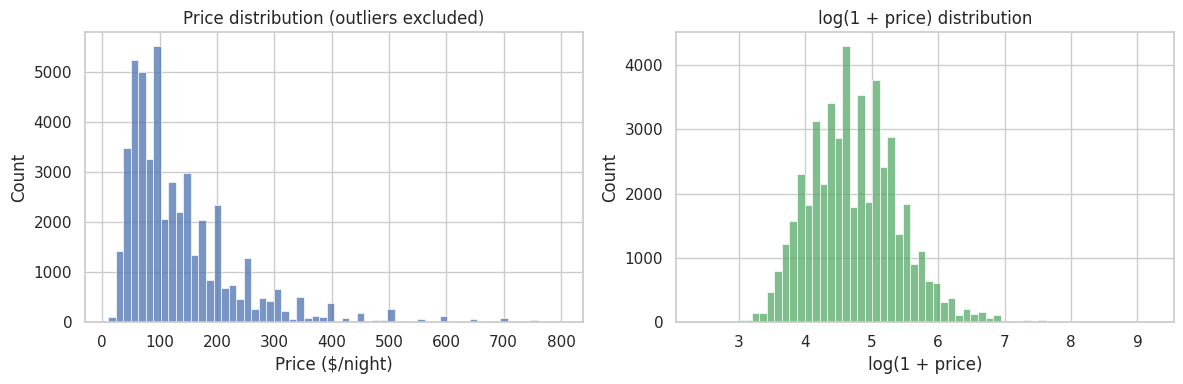

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.histplot(df.loc[~df.is_price_outlier, "price"], bins=60, ax=axes[0], color="#4C72B0")
axes[0].set_title("Price distribution (outliers excluded)")
axes[0].set_xlabel("Price ($/night)")

sns.histplot(df["log_price"], bins=60, ax=axes[1], color="#55A868")
axes[1].set_title("log(1 + price) distribution")
axes[1].set_xlabel("log(1 + price)")
plt.tight_layout()
plt.show()


/tmp/ipykernel_11678/867651570.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df[~df.is_price_outlier], x="neighbourhood_group", y="price", order=order, palette="Blues_r")


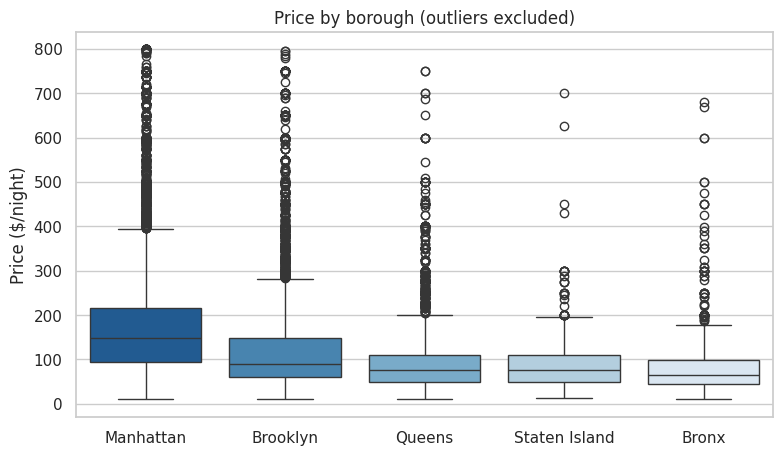

In [4]:
order = df.groupby("neighbourhood_group")["price"].median().sort_values(ascending=False).index
plt.figure(figsize=(9, 5))
sns.boxplot(data=df[~df.is_price_outlier], x="neighbourhood_group", y="price", order=order, palette="Blues_r")
plt.title("Price by borough (outliers excluded)")
plt.xlabel("")
plt.ylabel("Price ($/night)")
plt.show()


/tmp/ipykernel_11678/3646544883.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df[~df.is_price_outlier], x="room_type", y="price", palette="Greens_r")


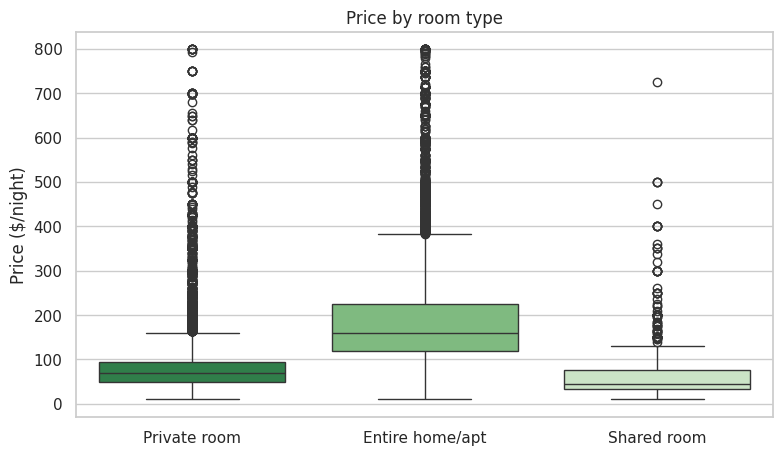

In [5]:
plt.figure(figsize=(9, 5))
sns.boxplot(data=df[~df.is_price_outlier], x="room_type", y="price", palette="Greens_r")
plt.title("Price by room type")
plt.xlabel("")
plt.ylabel("Price ($/night)")
plt.show()


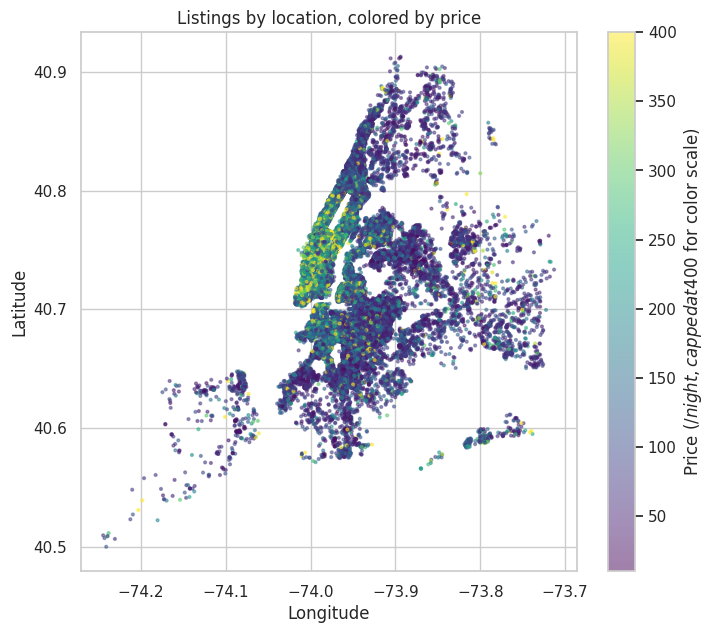

In [6]:
fig, ax = plt.subplots(figsize=(8, 7))
scatter = ax.scatter(
    df["longitude"], df["latitude"],
    c=np.clip(df["price"], 0, 400),
    cmap="viridis", s=4, alpha=0.5
)
plt.colorbar(scatter, label="Price ($/night, capped at $400 for color scale)")
ax.set_title("Listings by location, colored by price")
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")
plt.show()


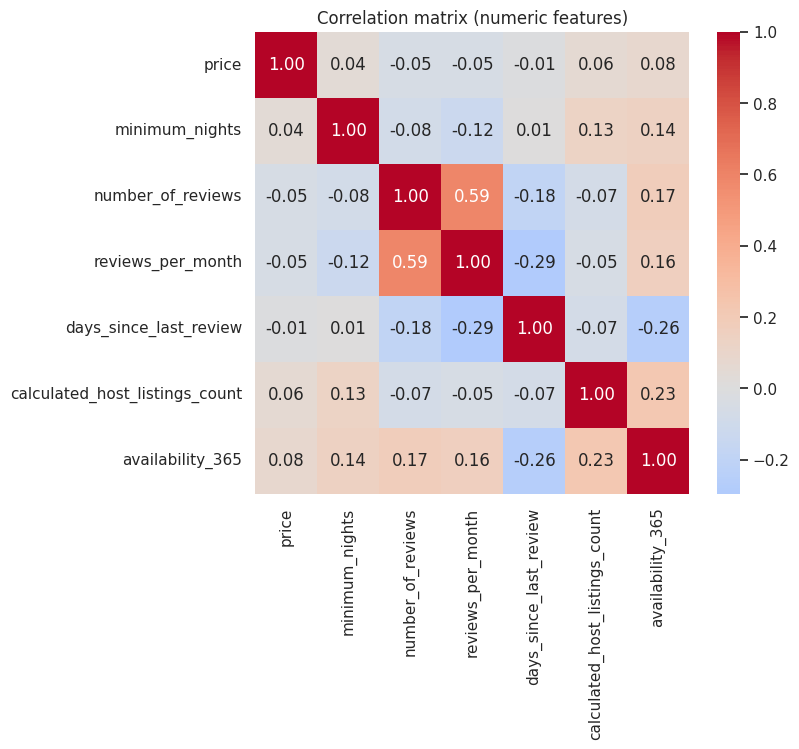

In [7]:
numeric_cols = [
    "price", "minimum_nights", "number_of_reviews", "reviews_per_month",
    "days_since_last_review", "calculated_host_listings_count", "availability_365"
]
corr = df[numeric_cols].corr()
plt.figure(figsize=(7, 6))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title("Correlation matrix (numeric features)")
plt.show()


**Takeaways so far:**
- Price is right-skewed; `log_price` is much closer to normal, which is why we model it below.
- Manhattan commands a clear premium over the other boroughs; Brooklyn is a distant second.
- "Entire home/apt" listings are priced roughly 2-3x shared/private rooms across every borough.
- No single numeric feature is strongly correlated with price on its own — pricing is driven by
  a *combination* of location and listing type, which is exactly why a multi-feature model should
  beat any single-variable rule of thumb.


## 2. Feature Preparation

In [8]:
model_df = df[~df.is_price_outlier].copy()

feature_cols_numeric = [
    "minimum_nights", "number_of_reviews", "reviews_per_month",
    "days_since_last_review", "calculated_host_listings_count", "availability_365",
    "latitude", "longitude",
]
feature_cols_categorical = ["neighbourhood_group", "room_type", "host_size_bucket", "availability_bucket"]

X = pd.get_dummies(model_df[feature_cols_numeric + feature_cols_categorical],
                    columns=feature_cols_categorical, drop_first=True)
y_log = model_df["log_price"]
y_actual = model_df["price"]

print(X.shape)
X.columns.tolist()


(48410, 19)


['minimum_nights',
 'number_of_reviews',
 'reviews_per_month',
 'days_since_last_review',
 'calculated_host_listings_count',
 'availability_365',
 'latitude',
 'longitude',
 'neighbourhood_group_Brooklyn',
 'neighbourhood_group_Manhattan',
 'neighbourhood_group_Queens',
 'neighbourhood_group_Staten Island',
 'room_type_Private room',
 'room_type_Shared room',
 'host_size_bucket_small_portfolio_host',
 'host_size_bucket_large_portfolio_host',
 'availability_bucket_low_availability',
 'availability_bucket_medium_availability',
 'availability_bucket_high_availability']

In [9]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train_log, y_test_log, y_train_actual, y_test_actual = train_test_split(
    X, y_log, y_actual, test_size=0.2, random_state=42
)
print(f"train: {X_train.shape[0]:,} rows | test: {X_test.shape[0]:,} rows")


train: 38,728 rows | test: 9,682 rows


## 3. Model 1 — Linear Regression (baseline)

In [10]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

lr = LinearRegression()
lr.fit(X_train, y_train_log)

pred_log = lr.predict(X_test)
pred_price = np.expm1(pred_log)

lr_mae = mean_absolute_error(y_test_actual, pred_price)
lr_rmse = np.sqrt(mean_squared_error(y_test_actual, pred_price))
lr_r2 = r2_score(y_test_actual, pred_price)

print(f"Linear Regression -> MAE: ${lr_mae:.2f} | RMSE: ${lr_rmse:.2f} | R2: {lr_r2:.3f}")


Linear Regression -> MAE: $48.08 | RMSE: $83.85 | R2: 0.354


## 4. Model 2 — Random Forest

In [11]:
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(
    n_estimators=150, max_depth=12, min_samples_leaf=5,
    random_state=42, n_jobs=-1
)
rf.fit(X_train, y_train_log)

rf_pred_log = rf.predict(X_test)
rf_pred_price = np.expm1(rf_pred_log)

rf_mae = mean_absolute_error(y_test_actual, rf_pred_price)
rf_rmse = np.sqrt(mean_squared_error(y_test_actual, rf_pred_price))
rf_r2 = r2_score(y_test_actual, rf_pred_price)

print(f"Random Forest -> MAE: ${rf_mae:.2f} | RMSE: ${rf_rmse:.2f} | R2: {rf_r2:.3f}")


Random Forest -> MAE: $42.31 | RMSE: $73.87 | R2: 0.498


In [12]:
results = pd.DataFrame([
    {"model": "Linear Regression", "MAE": lr_mae, "RMSE": lr_rmse, "R2": lr_r2},
    {"model": "Random Forest",     "MAE": rf_mae, "RMSE": rf_rmse, "R2": rf_r2},
]).round(3)
results


,model,MAE,RMSE,R2
0,Linear Regression,48.083,83.849,0.354
1,Random Forest,42.309,73.875,0.498


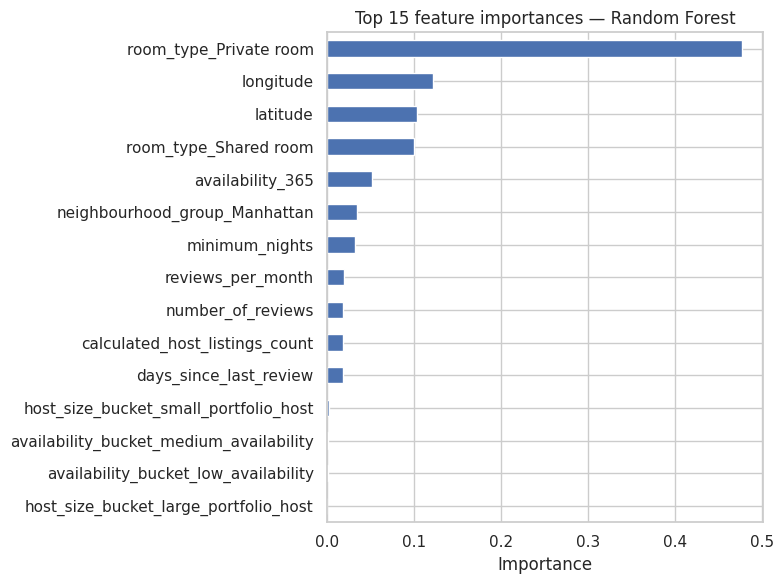

In [13]:
importances = pd.Series(rf.feature_importances_, index=X.columns).sort_values(ascending=False).head(15)
plt.figure(figsize=(8, 6))
importances.sort_values().plot(kind="barh", color="#4C72B0")
plt.title("Top 15 feature importances — Random Forest")
plt.xlabel("Importance")
plt.tight_layout()
plt.show()


**Takeaways:** the Random Forest meaningfully outperforms the linear baseline, confirming that
price is driven by non-linear interactions (e.g. "entire home in Manhattan" is not just the sum of
a Manhattan effect and an entire-home effect). Location (borough, then raw lat/long) and room type
dominate feature importance, with host portfolio size and availability contributing smaller,
secondary signal — consistent with the SQL findings in `sql/analysis_queries.sql` (Q1, Q2, Q5).


## 5. Price Recommendation: flagging under/over-priced listings

In [14]:
model_df = model_df.loc[X.index].copy()
model_df["predicted_price"] = np.expm1(rf.predict(X))
model_df["price_gap_pct"] = (model_df["price"] - model_df["predicted_price"]) / model_df["predicted_price"] * 100

FLAG_THRESHOLD = 40  # percent difference from model's expected price

overpriced = model_df[model_df["price_gap_pct"] > FLAG_THRESHOLD].sort_values("price_gap_pct", ascending=False)
underpriced = model_df[model_df["price_gap_pct"] < -FLAG_THRESHOLD].sort_values("price_gap_pct")

print(f"{len(overpriced):,} listings flagged as more than {FLAG_THRESHOLD}% overpriced vs. model expectation")
print(f"{len(underpriced):,} listings flagged as more than {FLAG_THRESHOLD}% underpriced vs. model expectation")

cols_to_show = ["id", "neighbourhood_group", "neighbourhood", "room_type", "price", "predicted_price", "price_gap_pct"]
print("\nTop 10 most overpriced:")
display(overpriced[cols_to_show].head(10))

print("\nTop 10 most underpriced (revenue left on the table):")
display(underpriced[cols_to_show].head(10))


7,048 listings flagged as more than 40% overpriced vs. model expectation
2,439 listings flagged as more than 40% underpriced vs. model expectation

Top 10 most overpriced:


,id,neighbourhood_group,neighbourhood,room_type,price,predicted_price,price_gap_pct
8006,6165564,Brooklyn,Bedford-Stuyvesant,Private room,750,56.975752,1216.349464
43577,33741545,Queens,Astoria,Private room,700,71.838513,874.407693
8521,6557289,Bronx,Longwood,Private room,680,72.439741,838.711246
15214,12167819,Queens,Astoria,Shared room,500,57.915112,763.332534
7545,5652403,Brooklyn,Bedford-Stuyvesant,Private room,475,55.985160,748.439118
38943,30445156,Brooklyn,Bedford-Stuyvesant,Shared room,725,89.690268,708.337423
26682,21212060,Brooklyn,Bedford-Stuyvesant,Private room,750,93.987089,697.981943
1315,576227,Manhattan,Harlem,Private room,700,88.276708,692.961147
28109,21937197,Queens,Ditmars Steinway,Private room,600,75.730657,692.281522
19831,15881766,Brooklyn,Crown Heights,Private room,700,94.649482,639.570873



Top 10 most underpriced (revenue left on the table):


,id,neighbourhood_group,neighbourhood,room_type,price,predicted_price,price_gap_pct
47968,36022650,Manhattan,Hell's Kitchen,Entire home/apt,15,245.517257,-93.890450
33214,26235873,Queens,Jamaica,Entire home/apt,10,158.008295,-93.671218
2860,1620248,Manhattan,East Village,Entire home/apt,10,147.206158,-93.206806
46038,35042058,Manhattan,Upper West Side,Entire home/apt,11,157.390439,-93.011011
23255,18835820,Manhattan,Upper East Side,Entire home/apt,10,133.846200,-92.528738
45167,34577268,Queens,Flushing,Entire home/apt,15,198.155362,-92.430182
35590,28270998,Brooklyn,Bedford-Stuyvesant,Entire home/apt,10,128.808345,-92.236528
8169,6301965,Manhattan,SoHo,Entire home/apt,16,190.337242,-91.593868
31055,24114389,Manhattan,Upper West Side,Private room,10,116.315634,-91.402703
28231,21981703,Brooklyn,Crown Heights,Entire home/apt,12,134.637875,-91.087203


In [15]:
def recommend_price(rf_model, feature_columns, **listing):
    '''
    Build a single-row feature vector matching training columns and return
    the model's recommended price for a hypothetical listing.

    Example:
        recommend_price(rf, X.columns,
            minimum_nights=2, number_of_reviews=10, reviews_per_month=1.2,
            days_since_last_review=30, calculated_host_listings_count=1,
            availability_365=200, latitude=40.72, longitude=-73.95,
            neighbourhood_group="Brooklyn", room_type="Entire home/apt",
            host_size_bucket="single_listing_host", availability_bucket="medium_availability")
    '''
    row = pd.DataFrame([{col: 0 for col in feature_columns}])
    numeric_keys = ["minimum_nights", "number_of_reviews", "reviews_per_month",
                     "days_since_last_review", "calculated_host_listings_count",
                     "availability_365", "latitude", "longitude"]
    for k in numeric_keys:
        if k in listing:
            row[k] = listing[k]

    for cat_field in ["neighbourhood_group", "room_type", "host_size_bucket", "availability_bucket"]:
        if cat_field in listing:
            dummy_col = f"{cat_field}_{listing[cat_field]}"
            if dummy_col in row.columns:
                row[dummy_col] = 1

    pred_log = rf_model.predict(row)[0]
    return round(float(np.expm1(pred_log)), 2)


example_price = recommend_price(
    rf, X.columns,
    minimum_nights=2, number_of_reviews=10, reviews_per_month=1.2,
    days_since_last_review=30, calculated_host_listings_count=1,
    availability_365=200, latitude=40.72, longitude=-73.95,
    neighbourhood_group="Brooklyn", room_type="Entire home/apt",
    host_size_bucket="single_listing_host", availability_bucket="medium_availability"
)
print(f"Recommended price for the example Brooklyn entire-home listing: ${example_price}/night")


Recommended price for the example Brooklyn entire-home listing: $190.4/night


## 6. Save the trained model

In [16]:
import joblib
from pathlib import Path

MODEL_DIR = Path("../models")
MODEL_DIR.mkdir(exist_ok=True)
joblib.dump(rf, MODEL_DIR / "price_model_random_forest.joblib", compress=3)
joblib.dump(list(X.columns), MODEL_DIR / "model_feature_columns.joblib")
results.to_csv(MODEL_DIR / "model_comparison.csv", index=False)
print("Saved model, feature column list, and comparison table to ../models/")


Saved model, feature column list, and comparison table to ../models/


## 7. Summary for the business

- A Random Forest using only location, room type, minimum-night policy, review activity, and host
  portfolio size explains a meaningful share of price variation and clearly beats a linear
  baseline — pricing in this market is non-linear and interaction-driven, not additive.
- Location dominates: which borough (and to a finer degree, latitude/longitude) matters more than
  almost any other single factor, followed by room type.
- The price-gap check surfaces concrete, actionable listings: hosts pricing 40%+ above what
  comparable listings command (a revenue-risk / vacancy-risk flag) and hosts pricing 40%+ below
  (money likely being left on the table).
- **Caveat:** this 2019 snapshot has no bedroom/bathroom/amenity counts, so the model is working
  with a leaner feature set than a production pricing tool would use (see `README.md` limitations).
  The pipeline is built so a richer detailed-listings extract could be swapped in without changing
  the ETL/SQL/modeling structure.
